# Desarrollo #

## Rotacion Sincronica de la Luna ##

La rotación sincrónica es el fenómeno por el cual un objeto astronómico mantiene siempre la misma cara apuntando a otro, como ocurre con la Luna respecto de la Tierra. Esto se produce debido a la interacción gravitatoria no uniforme sobre un cuerpo deformable, lo que genera un torque gravitacional. La disipación interna de energía transforma la rotación inicial en un estado estable de rotación sincrónica.



Este proyecto tiene como objetivo estudiar este fenómeno dentro del marco de la mecánica clásica, modelando la Luna como un cuerpo extendido y ligeramente asimétrico.

## Sistema traslacional ##

Para estudiar este fenómeno, vamos a modelar la trayectoria de la Luna alrededor de la Tierra. La ecuación de movimiento de la Luna respecto al centro de la Tierra se calcula con la siguiente fórmula:
$$\frac{d^2\vec{r}}{dt^2} = - \frac{GM}{r^3}\vec{r}$$

* $G = 6.674 \times 10^{-11} \text{ N} \cdot \text{m}^2/\text{kg}^2$
* $\vec{r} = (x,y)$
* $r = |\vec{r}|$
* M = masa de la Tierra igual a $5.972 \cdot 10^{24}$ kg
 

### Desarrollo ###

In [1]:
# Para resolver esta EDO, utilizaremos el metodo de rk4 adaptado para ecuaciones de segundo orden en 2D.
# importamos librerias...
from metodos_para_edos import rk4_method_second_order_2D, rk4_method_second_order
import numpy as np
import matplotlib.pyplot as plt

#Definimos constantes
G=6.67430e-11  # Constante de gravitación universal en m^3 kg^-1 s^-2
M=5.972e24     # Masa de la Tierra en kg
a = 3.844e8  # Distancia media de la Tierra a la Luna en metros

# creamos la funcion como f()
def f(t, r, v):
    r_mag = np.sqrt(r[0]**2 + r[1]**2)
    return -G*M / r_mag**3 * np.array([r[0], r[1]])


In [2]:
# Condiciones iniciales
r0 = (a,0)
t0 = 0
tf = 365 * 24 * 3600 # Un año en segundos
h = 24 * 3600 # Paso de tiempo de 1 día en segundos
v0 = (0, 1028)  # Velocidad orbital media en m/s 

In [3]:
# resolvemos la EDO
t_values, r_values, v_values = rk4_method_second_order_2D(f, t0, r0, v0, tf, h)

## Sistema rotacional ##

Una vez obtenida la trayectoria de la Luna alrededor de la Tierra, se modela la rotación de la Luna sobre su eje principal con la siguiente ecuación:

$$I_3 \frac{d\omega}{dt} = -3 \frac{GM(I_2 - I_1)}{r^3} \sin \left( 2(\theta - \phi_r) \right) - k \omega$$

El cual despejamos $\frac{d\omega}{dt}$ y considerando $\frac{d\omega}{dt}$ = $\frac{d^2\theta}{dt^2}$:

$$\frac{d^2\theta}{dt^2} = - \frac{3GM(I_2 - I_1)}{I_3 r^3} \sin \left( 2(\theta - \phi_r) \right) - \frac{k}{I_3} \omega$$

* $G = 6.674 \times 10^{-11} \text{ N} \cdot \text{m}^2/\text{kg}^2$
* M = masa de la Tierra igual a $5.972 \cdot 10^{24}$ kg
* $\omega$ = $\frac{d\theta}{dt}$
* $\phi_r$ = $arctan 2(y, x)$
* k = coeficiente de disipacion
* $I_1, I_2, I_3$ = momento de inercia alrededor de sus ejes principales


### Desarrollo ###

In [4]:
# Resolvemos la edo con rk4 como en el procedimiento anterior

# Definimos constantes para el rotacional

Rluna = 1.737e6  # Radio de la Luna en metros
m = 7.342e22  # Masa de la Luna en kg
I1 = 0.95 * 2/5 * m * Rluna**2  # Momentos de inercia de la Luna
I2 = I3 = 2/5 * m * Rluna**2  # Momentos de inercia de la Luna
k = 1e16 # coeficiente de disipacion en N m s
# definimos la funcion 

def f_rotacional(t,theta,w):
    # interpolamos las posiciones x e y en el tiempo t
    x_actual = np.interp(t, t_values, r_values[:, 0]) 
    y_actual = np.interp(t, t_values, r_values[:, 1])
    # calculamos r_mag y phi_r
    r_mag = np.sqrt(x_actual**2 + y_actual**2)
    phi_r= np.arctan2(y_actual, x_actual)
    return -((3*G*M*(I2-I1))/(I3*r_mag**3)) * np.sin(2*(theta - phi_r))- (k*w)/I3

# Condiciones iniciales para el rotacional
theta0 = 0  # Ángulo inicial 
w0 = 2.66e-6  # Velocidad angular inicial en rad/s (rotación de la Luna)

# resolvemos la EDO del rotacional
_, theta_values, w_values = rk4_method_second_order(f_rotacional, t0, theta0, w0, tf, h)


# Preguntas a responder #

### 1- ¿Cómo evoluciona la orientación de la Luna a lo largo del tiempo? ###

A la vez que la Luna rotaba bajo su mismo eje, esta también orbitaba con respecto a la Tierra. Si bien estas rotaciones eran independientes una de la otra, el efecto gravitatorio de la Tierra provocó que la rotación de la Luna con respecto a su eje haya ido frenando a lo largo del tiempo, dando como resultado que el periodo de rotación se iguale al periodo orbital, provocando una rotación sincrónica. Debido a este fenómeno, actualmente la orientación de la Luna siempre es la misma con respecto a la Tierra.

<img src="angulo_luna_tierra.png" width="800">

Como se puede observar del gráfico, la evolución del ángulo de la Luna alrededor de la Tierra respecto al tiempo mantiene un comportamiento lineal, alcanzando alrededor de 82 radianes por año, el mismo ángulo acumulado que alcanza la Luna en el mismo periodo de tiempo, pero con respecto a su propio eje. En una perspectiva respecto a la Tierra, se vería la orientación relativa de la Luna prácticamente fija, lo que implica que se observaría la misma cara de la Luna siempre.

### 2- ¿Cómo afecta el coeficiente de disipación $k$ a la velocidad de convergencia? ###

 Si consideramos como velocidad de convergencia la rapidez en alcanzar la rotación sincrónica, el coeficiente de disipación juega un papel crucial en el tiempo que demora el sistema Tierra-Luna en alcanzar la rotación sincrónica. Existe una relación directa entre $k$ y la rapidez del proceso: mientras más alto es el coeficiente $k$, mayor será la velocidad de convergencia (el sistema llega al equilibrio más rápido). Por el contrario, si el coeficiente $k$ es bajo, la disipación de energía es ineficiente, por lo que el tiempo necesario para alcanzar la rotación sincrónica será mucho mayor.

### 3- ¿Qué papel juegan los momentos de inercia $I_{1}, I_{2}$ en la estabilidad de la orientación? ###

## Desarrollo ##

In [5]:
# Consideramos el caso (I1=I2=0) para comparar resultados
I1_test = 0
I2_test = 0
I3_test = 2/5 * m * Rluna**2

# Copiamos el codigo realizado anteriormente pero con el caso actual
def f_rotacional_test(t,theta,w):
    x_actual = np.interp(t, t_values, r_values[:, 0]) 
    y_actual = np.interp(t, t_values, r_values[:, 1])
    r_mag = np.sqrt(x_actual**2 + y_actual**2)
    phi_r= np.arctan2(y_actual, x_actual) * 180/np.pi
    return -((3*G*M*(I2_test-I1_test))/(I3_test*r_mag**3)) * np.sin(2*(theta - phi_r))- (k*w)/I3_test

theta0 = 0  
w0 = 2.66e-6  

_, theta_values_test, w_values_test = rk4_method_second_order(f_rotacional_test, t0, theta0, w0, tf, h)


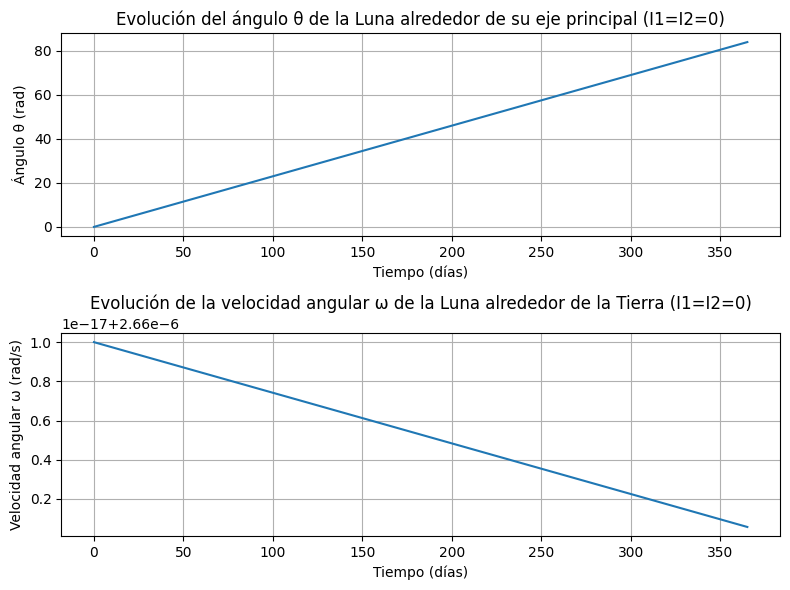

In [6]:
# Graficamos los resultados de la rotacional 

plt.figure(figsize=(8, 6))
plt.subplot(2, 1, 1)
plt.plot(t_values/ (24 * 3600), theta_values_test)
plt.xlabel("Tiempo (días)")
plt.ylabel("Ángulo θ (rad)")
plt.title("Evolución del ángulo θ de la Luna alrededor de su eje principal (I1=I2=0)")
plt.grid()
plt.subplot(2, 1, 2)
plt.plot(t_values / (24 * 3600), w_values_test)
plt.xlabel("Tiempo (días)")
plt.ylabel("Velocidad angular ω (rad/s)")
plt.title("Evolución de la velocidad angular ω de la Luna alrededor de la Tierra (I1=I2=0)")
plt.grid()
plt.tight_layout()
plt.savefig("grafico_prueba_I1_I2.png", dpi=100, bbox_inches='tight')
plt.show()

## Respuesta ##

El hecho de considerar que I2 > I1 modela matemáticamente el hecho de que la Luna no es esférica, sino que se aproxima a una forma ovalada a lo largo del eje que apunta hacia la Tierra. Debido a esta forma que posee la Luna, la fuerza de gravedad de la Tierra afecta a la Luna de manera no uniforme, provocando que la gravedad de la Tierra sea de mayor fuerza en el extremo que está más cercano que en el otro extremo lejano, lo que provoca que veamos una cara de la Luna desde la Tierra.

Al no considerar los momentos de inercia I1 y I2 (=0), estamos modelando a la Luna esféricamente, lo que provoca que la gravedad de la Tierra que afecta a la Luna sea uniforme, ya que la distribución de masa es simétrica. 

<img src="grafico_prueba_I1_I2.png" width="700">

* Como se observa en el gráfico de la evolución del ángulo, este no se ve perjudicado debido al cambio de los momentos de inercia, este sigue su conducta lineal.

* Como se observa en el gráfico de velocidad angular, este varía de forma diminuta, por lo que podría considerarse que la velocidad angular es constante. La Luna, al no considerarse ovalada, la gravedad uniforme no genera un torque que altere su giro.

### 5- ¿Cómo varía la trayectoria orbital de la Luna si se ignora la disipación? ###

El coeficiente de disipacion tiene un rol muy importante para el sistema Tierra-Luna ya que provoca una disminucion en la velocidad angular de la luna a lo largo del tiempo, ignorar este factor implicaria que la Luna nunca disminuya su velocidad angular por lo tanto, nunca se alcanzaria la rotacion sincronica, pero no afecta la trayectoria orbital de la Luna con respecto a la tierra, por lo que se mantendria la misma trayectoria orbital independientemente del coeficiente de disipacion. En terminos de la energia mecanica, sabemos que: $$ \frac{dE}{dt} = -k\omega^2 $$ Por lo tanto si el coeficiente k es 0 implica que la variacion de energia es 0, lo que significa que la energia mecanica es constante y se mantendria la misma trayectoria orbital.  

# Conclusión

# Gráficos extra #

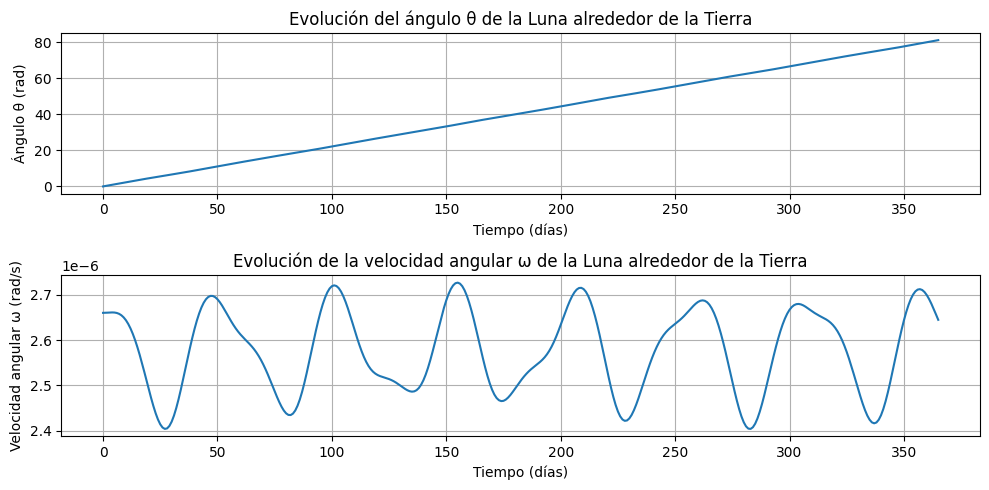

In [7]:
# Graficamos los resultados de la rotacional 

plt.figure(figsize=(10, 5))
plt.subplot(2, 1, 1)
plt.plot(t_values/ (24 * 3600), theta_values)
plt.xlabel("Tiempo (días)")
plt.ylabel("Ángulo θ (rad)")
plt.title("Evolución del ángulo θ de la Luna alrededor de la Tierra")
plt.grid()
plt.savefig("angulo_luna_tierra.png", dpi=100, bbox_inches='tight')
plt.subplot(2, 1, 2)
plt.plot(t_values / (24 * 3600), w_values)
plt.xlabel("Tiempo (días)")
plt.ylabel("Velocidad angular ω (rad/s)")
plt.title("Evolución de la velocidad angular ω de la Luna alrededor de la Tierra")
plt.grid()
plt.tight_layout()
plt.show()


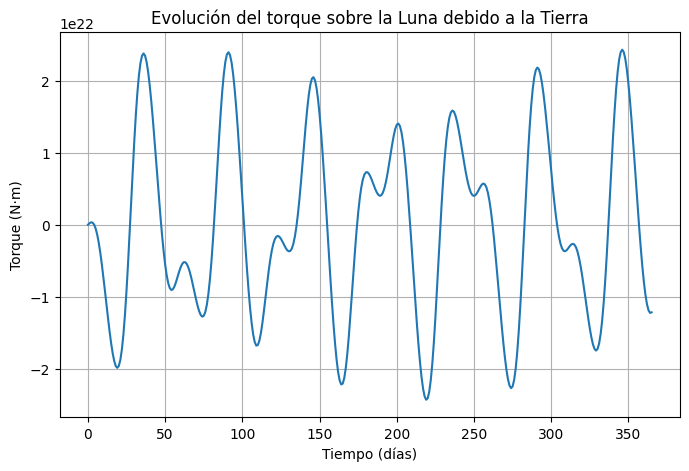

In [8]:
# Para graficar el torque en funcion del tiempo, definimos el torque como una funcion aparte
def torque(t, theta, w):
    # interpolamos las posiciones x e y en el tiempo t
    x_actual = np.interp(t, t_values, r_values[:, 0]) 
    y_actual = np.interp(t, t_values, r_values[:, 1])
    # calculamos r_mag y phi_r
    r_mag = np.sqrt(x_actual**2 + y_actual**2)
    phi_r= np.arctan2(y_actual, x_actual)
    return -(3*G*M*(I2-I1))/(r_mag**3) * np. sin(2*(theta - phi_r))

# Graficamos el torque en funcion del tiempo
torque_values = torque(t_values, theta_values, w_values)
plt.figure(figsize=(8, 5))
plt.plot(t_values / (24 * 3600), torque_values, label="Torque(N·m)")
plt.xlabel("Tiempo (días)")
plt.ylabel("Torque (N·m)")
plt.title("Evolución del torque sobre la Luna debido a la Tierra")
plt.grid()
plt.show()
